# Lab-2 Iris classification (Multi-class classification)

- ใช้ dataset จากไฟล์ `iris.csv`
  * **sepal.length**: ความยาวกลีบเลี้ยง (cm)
  * **sepal.width**: ความกว้างกลีบเลี้ยง (cm)
  * **petal.length**: ความยาวกลีบดอก (cm)
  * **petal.width**: ความกว้างกลีบดอก (cm)
  * **variety**: สายพันธุ์

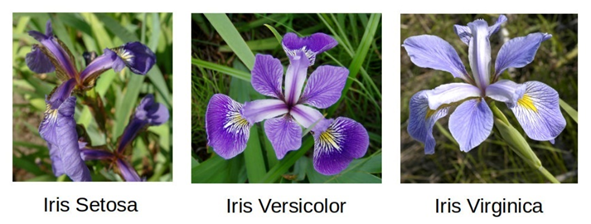

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Preparation
* เชื่อมต่อ google drive
* upload ไฟล์ iris.csv

* สร้าง DataFrame จากไฟล์ iris.csv

In [ ]:
import pandas as pd
iris_df = pd.read_csv('/content/drive/MyDrive/ML dataset/iris.csv')
iris_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


## แบ่ง Train / Test Dataset

* ใช้ train_test_split จาก library sklearn.model_selection
```
from sklearn.model_selection import train_test_split
```

In [ ]:
from sklearn.model_selection import train_test_split

* เรียกใช้ train_test_split
```
train_test_split(X, y, test_size=?)
```

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(iris_df.iloc[:, :4], iris_df['variety'], test_size=0.2, random_state=888)
X_test

,sepal.length,sepal.width,petal.length,petal.width
76,6.8,2.8,4.8,1.4
83,6.0,2.7,5.1,1.6
146,6.3,2.5,5.0,1.9
134,6.1,2.6,5.6,1.4
125,7.2,3.2,6.0,1.8
61,5.9,3.0,4.2,1.5
57,4.9,2.4,3.3,1.0
128,6.4,2.8,5.6,2.1
141,6.9,3.1,5.1,2.3
86,6.7,3.1,4.7,1.5


## สร้างโมเดล KNN

* ใช้ KNeighborsClassifier จาก library sklearn.neighbors
```
from sklearn.neighbors import KNeighborsClassifier
```

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

* สร้างโมเดลเปล่า
```
KNeighborsClassifier(n_neighbors=?)
```

In [ ]:
iris_classifier = KNeighborsClassifier(n_neighbors=7)

* ให้โมเดลเรียนรู้ข้อมูลจาก training data
```
fit()
```

In [ ]:
iris_classifier.fit(X_train, y_train)
iris_classifier.classes_

array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

* ทดสอบการ predict (classify) ด้วย testing data

In [ ]:
y_predict = iris_classifier.predict(X_test)
y_predict

array(['Versicolor', 'Virginica', 'Virginica', 'Virginica', 'Virginica',
       'Versicolor', 'Versicolor', 'Virginica', 'Virginica', 'Versicolor',
       'Setosa', 'Versicolor', 'Setosa', 'Versicolor', 'Versicolor',
       'Versicolor', 'Versicolor', 'Setosa', 'Setosa', 'Setosa',
       'Virginica', 'Virginica', 'Setosa', 'Versicolor', 'Virginica',
       'Virginica', 'Virginica', 'Setosa', 'Setosa', 'Setosa'],
      dtype=object)

## วัดประสิทธิภาพของโมเดลที่ได้

### Accuracy
ความแม่นยำในการทำนาย หรือสัดส่วนของการทำนายที่ถูกต้อง
```python
from sklearn.metrics import accuracy_score
accuracy_score(y_true, y_pred)
```

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

0.9333333333333333

### Confusion Matrix and Classification Report

ตารางที่ใช้ในการแสดงผลการทำงานของโมเดลในการจำแนกประเภท (classification) โดยแสดงค่าทั้งหมดของ True Positives (TP), True Negatives (TN), False Positives (FP) และ False Negatives (FN)
```
                Predicted Negative   Predicted Positive
Actual Negative         TN                   FP
Actual Positive         FN                   TP
```
  * row - true label
  * column - predict label

```
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(true, predict)
print(classification_report(<true label>, <predicted label>))
```

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
cm = (confusion_matrix(y_test, y_predict))
cm

array([[ 9,  0,  0],
       [ 0, 10,  2],
       [ 0,  0,  9]])

In [ ]:
pd.DataFrame(cm, columns=iris_classifier.classes_,index=iris_classifier.classes_)
#row-คือค่าจริง col-คือค่าที่ทำนาย

,Setosa,Versicolor,Virginica
Setosa,9,0,0
Versicolor,0,10,2
Virginica,0,0,9


In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00         9
  Versicolor       1.00      0.83      0.91        12
   Virginica       0.82      1.00      0.90         9

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.95      0.93      0.93        30



### Kappa (Cohen's Kappa)

การวัดความเห็นพ้องระหว่างผลการทำนายของโมเดลและค่าจริง

**สูตรการคำนวณ**:

$Kappa = \frac{P_o - P_e}{1 - P_e}$

- $P_o$: สัดส่วนความแม่นยำที่เกิดขึ้นจริง (observed accuracy)
- $P_e$: สัดส่วนความแม่นยำที่เกิดขึ้นแบบสุ่ม (expected accuracy)

```python
from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_true, y_pred)
```

In [ ]:
from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test, y_predict)

np.float64(0.9)

### MCC (Matthews Correlation Coefficient)

การวัดประสิทธิภาพของโมเดลโดยพิจารณาความสัมพันธ์ระหว่างค่าทำนายและค่าจริง

**สูตรการคำนวณ**:

$MCC = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$

```python
from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_true, y_pred)
```

In [ ]:
from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_test, y_predict)

np.float64(0.9060453698477576)

## Prediction

* สร้าง DataFrame

In [ ]:
iris_unknown = pd.DataFrame([[5.2, 2.7, 3.9, 1.4], [3.2, 3.7, 4.9, 3.4]],columns=iris_df.columns[:-1])
iris_unknown

,sepal.length,sepal.width,petal.length,petal.width
0,5.2,2.7,3.9,1.4
1,3.2,3.7,4.9,3.4


* Predict โดยใช้โมเดลเดิม

In [ ]:
iris_classifier.predict(iris_unknown)

array(['Versicolor', 'Virginica'], dtype=object)